In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

In [7]:
df = pd.read_csv('daily-minimum-temperatures-in-me.csv')
df.columns = ['date','temp']
df

,date,temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [8]:
df['date'] = pd.to_datetime(df['date'])
df

,date,temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [9]:
df = df.sort_values('date').reset_index(drop=True)

In [10]:
df['temp'] = pd.to_numeric(df['temp'],errors='coerce')
df

,date,temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [11]:
df = df.dropna().reset_index(drop=True)
df.shape

(3647, 2)

In [12]:
from numpy.fft import fft

y = df['temp'].values
x = (y - y.mean())
c0= (x**2).mean()

max_lag = 400
acf = np.array([(x[:len(x)-lag] * x[lag:]).mean()/c0 for lag in range(max_lag+1)])


In [13]:
df['lag_1'] = df['temp'].shift(1)
df['lag_7'] = df['temp'].shift(7)
df

,date,temp,lag_1,lag_7
0,1981-01-01,20.7,NaN,NaN
1,1981-01-02,17.9,20.7,NaN
2,1981-01-03,18.8,17.9,NaN
3,1981-01-04,14.6,18.8,NaN
4,1981-01-05,15.8,14.6,NaN
...,...,...,...,...
3642,1990-12-27,14.0,14.6,15.4
3643,1990-12-28,13.6,14.0,13.1
3644,1990-12-29,13.5,13.6,13.2
3645,1990-12-30,15.7,13.5,13.9


In [14]:
df['ma_7'] = df['temp'].rolling(7).mean()
df['ma_14'] = df['temp'].rolling(14).mean() # mean average
df

,date,temp,lag_1,lag_7,ma_7,ma_14
0,1981-01-01,20.7,NaN,NaN,NaN,NaN
1,1981-01-02,17.9,20.7,NaN,NaN,NaN
2,1981-01-03,18.8,17.9,NaN,NaN,NaN
3,1981-01-04,14.6,18.8,NaN,NaN,NaN
4,1981-01-05,15.8,14.6,NaN,NaN,NaN
...,...,...,...,...,...,...
3642,1990-12-27,14.0,14.6,15.4,13.100000,13.742857
3643,1990-12-28,13.6,14.0,13.1,13.171429,13.821429
3644,1990-12-29,13.5,13.6,13.2,13.214286,13.828571
3645,1990-12-30,15.7,13.5,13.9,13.471429,13.978571


In [15]:
df['doy'] = df['date'].dt.day_of_year
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.day_of_week
df

,date,temp,lag_1,lag_7,ma_7,ma_14,doy,day,month,dow
0,1981-01-01,20.7,NaN,NaN,NaN,NaN,1,1,1,3
1,1981-01-02,17.9,20.7,NaN,NaN,NaN,2,2,1,4
2,1981-01-03,18.8,17.9,NaN,NaN,NaN,3,3,1,5
3,1981-01-04,14.6,18.8,NaN,NaN,NaN,4,4,1,6
4,1981-01-05,15.8,14.6,NaN,NaN,NaN,5,5,1,0
...,...,...,...,...,...,...,...,...,...,...
3642,1990-12-27,14.0,14.6,15.4,13.100000,13.742857,361,27,12,3
3643,1990-12-28,13.6,14.0,13.1,13.171429,13.821429,362,28,12,4
3644,1990-12-29,13.5,13.6,13.2,13.214286,13.828571,363,29,12,5
3645,1990-12-30,15.7,13.5,13.9,13.471429,13.978571,364,30,12,6


In [16]:
df['diff_1'] = df['temp'].shift(1).diff(1)
df

,date,temp,lag_1,lag_7,ma_7,ma_14,doy,day,month,dow,diff_1
0,1981-01-01,20.7,NaN,NaN,NaN,NaN,1,1,1,3,NaN
1,1981-01-02,17.9,20.7,NaN,NaN,NaN,2,2,1,4,NaN
2,1981-01-03,18.8,17.9,NaN,NaN,NaN,3,3,1,5,-2.8
3,1981-01-04,14.6,18.8,NaN,NaN,NaN,4,4,1,6,0.9
4,1981-01-05,15.8,14.6,NaN,NaN,NaN,5,5,1,0,-4.2
...,...,...,...,...,...,...,...,...,...,...,...
3642,1990-12-27,14.0,14.6,15.4,13.100000,13.742857,361,27,12,3,1.7
3643,1990-12-28,13.6,14.0,13.1,13.171429,13.821429,362,28,12,4,-0.6
3644,1990-12-29,13.5,13.6,13.2,13.214286,13.828571,363,29,12,5,-0.4
3645,1990-12-30,15.7,13.5,13.9,13.471429,13.978571,364,30,12,6,-0.1


In [17]:
df_wo_nan = df.dropna().reset_index(drop=True)
df_wo_nan

,date,temp,lag_1,lag_7,ma_7,ma_14,doy,day,month,dow,diff_1
0,1981-01-14,21.5,16.7,15.8,18.128571,17.592857,14,14,1,2,3.4
1,1981-01-15,25.0,21.5,17.4,19.214286,17.900000,15,15,1,3,4.8
2,1981-01-16,20.7,25.0,21.8,19.057143,18.100000,16,16,1,4,3.5
3,1981-01-17,20.6,20.7,20.0,19.142857,18.228571,17,17,1,5,-4.3
4,1981-01-18,24.8,20.6,16.2,20.371429,18.957143,18,18,1,6,-0.1
...,...,...,...,...,...,...,...,...,...,...,...
3629,1990-12-27,14.0,14.6,15.4,13.100000,13.742857,361,27,12,3,1.7
3630,1990-12-28,13.6,14.0,13.1,13.171429,13.821429,362,28,12,4,-0.6
3631,1990-12-29,13.5,13.6,13.2,13.214286,13.828571,363,29,12,5,-0.4
3632,1990-12-30,15.7,13.5,13.9,13.471429,13.978571,364,30,12,6,-0.1


In [18]:
LOOKBACK = 30

tr_end = int(0.7 * len(df))
vl_end = int(0.85 * len(df))

In [19]:
df_wo_nan.columns

Index(['date', 'temp', 'lag_1', 'lag_7', 'ma_7', 'ma_14', 'doy', 'day',
       'month', 'dow', 'diff_1'],
      dtype='str')

In [20]:
features = ['lag_1','lag_7','ma_7','ma_14','doy','day','month', 'dow', 'diff_1']

In [21]:
Xraw = df_wo_nan[features].values.astype(np.float32)
yraw = df_wo_nan['temp'].values.astype(np.float32)

X_mean, X_std = Xraw[:tr_end].mean(0),Xraw[:tr_end].std(0)
y_mean, y_std = yraw[:tr_end].mean(0),yraw[:tr_end].std(0)

Xn = (Xraw - X_mean)/X_std
yn = (yraw - y_mean)/y_std

In [22]:
Xn

array([[ 1.4052356e+00,  1.1836706e+00,  2.1204274e+00, ...,
        -1.6007756e+00, -5.0071055e-01,  1.2181067e+00],
       [ 2.5862291e+00,  1.5772377e+00,  2.4428358e+00, ...,
        -1.6007756e+00, -5.8796513e-04,  1.7199693e+00],
       [ 3.4473701e+00,  2.6595476e+00,  2.3961716e+00, ...,
        -1.6007756e+00,  4.9953461e-01,  1.2539539e+00],
       ...,
       [ 6.4251053e-01,  5.4412377e-01,  6.6110575e-01, ...,
         1.5882794e+00,  9.9965721e-01, -1.4409164e-01],
       [ 6.1790645e-01,  7.1630943e-01,  7.3746568e-01, ...,
         1.5882794e+00,  1.4997798e+00, -3.6549665e-02],
       [ 1.1591951e+00, -2.4301063e-01,  8.6473191e-01, ...,
         1.5882794e+00, -1.5009557e+00,  7.8793877e-01]],
      shape=(3634, 9), dtype=float32)

In [23]:
def windows(X,y,L):
    Xw = np.stack([X[i:i+L] for i in range(len(X) - L)])
    return Xw, y[L:]

In [24]:
Xw,yw = windows(Xn,yn,LOOKBACK)
Xw,yw

(array([[[ 1.4052356e+00,  1.1836706e+00,  2.1204274e+00, ...,
          -1.6007756e+00, -5.0071055e-01,  1.2181067e+00],
         [ 2.5862291e+00,  1.5772377e+00,  2.4428358e+00, ...,
          -1.6007756e+00, -5.8796513e-04,  1.7199693e+00],
         [ 3.4473701e+00,  2.6595476e+00,  2.3961716e+00, ...,
          -1.6007756e+00,  4.9953461e-01,  1.2539539e+00],
         ...,
         [ 3.4473701e+00,  2.6841455e+00,  2.0398257e+00, ...,
          -1.3108615e+00, -1.0008332e+00,  2.8312364e+00],
         [ 9.8696691e-01,  2.1921866e+00,  1.7768080e+00, ...,
          -1.3108615e+00, -5.0071055e-01, -3.5854347e+00],
         [ 6.6711444e-01,  1.3804543e+00,  1.6622685e+00, ...,
          -1.3108615e+00, -5.8796513e-04, -4.6671751e-01]],
 
        [[ 2.5862291e+00,  1.5772377e+00,  2.4428358e+00, ...,
          -1.6007756e+00, -5.8796513e-04,  1.7199693e+00],
         [ 3.4473701e+00,  2.6595476e+00,  2.3961716e+00, ...,
          -1.6007756e+00,  4.9953461e-01,  1.2539539e+00],
       

In [25]:
def to_t(a,b):
    return (torch.tensor(a),torch.tensor(b).unsqueeze(-1))

In [26]:
tr = tr_end - LOOKBACK
val = vl_end - LOOKBACK


In [36]:
X_tr,y_tr = to_t(Xw[:tr],yw[:tr])
X_vl,y_vl = to_t(Xw[tr:tr+val],yw[tr:tr+val])
X_te,y_te = to_t(Xw[val:],yw[val:])

In [39]:
INPUT,HIDDEN = X_tr.shape[2],64

In [40]:
class RNNHead(nn.Module):
    def __init__(self,cell):
        super().__init__()
        cls = {'rnn':nn.RNN,'gru':nn.GRU,'lstm':nn.LSTM}[cell]
        self.nn= cls(INPUT,HIDDEN,batch_first = True)
        self.head = nn.Linear(HIDDEN,1)
    def forward(self,x):
        out, _ = self.nn(x)
        return self.head(out[:,-1])

In [41]:
class TransformerHead(nn.Module):
    def __init__(self, d=64, h=4, layers=2):
        super().__init__()
        # d = hidden dimension (размер скрытого представления)
        # h = количество голов внимания
        # layers = количество слоев Transformer
        
        self.proj = nn.Linear(INPUT, d)     # ← проецируем вход в размер d
        enc = nn.TransformerEncoderLayer(d, h, dim_feedforward=128, dropout=0.1,batch_first = True)
        self.enc = nn.TransformerEncoder(enc, layers)  # ← стек Transformer слоев
        self.head = nn.Linear(d, 1)          # ← финальный линейный слой
    
    def forward(self, x):
        out = self.enc(self.proj(x))    # ← (batch, seq, d) → кодируем
        return self.head(out[:, -1])    # ← берем последний выход, предсказываем

In [42]:
def train(model, epochs=60, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    h = {'train': [], 'val': []}
    
    for _ in range(epochs):              # ← range()
        model.train()
        opt.zero_grad()
        t1 = crit(model(X_tr), y_tr)
        t1.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        
        model.eval()
        with torch.no_grad():            # ← скобки!
            vl_ = crit(model(X_vl), y_vl).item()
        
        h['train'].append(t1.item())
        h['val'].append(vl_)
    
    return model, h

In [43]:
def predict(m):
    m.eval()
    with torch.no_grad():
        return m(X_te).numpy().squeeze()*y_std + y_mean

In [44]:
models,history,preds = {},{},{}
for name in ['rnn','gru','lstm']:
    m,h = train(RNNHead(name))
    models[name] = m
    history[name] = h
    preds[name] = predict(m)

m,h = train(TransformerHead())
models['transformer'] = m
history['transformer'] = h
preds['transformer'] = predict(m)

true_te = y_te.numpy().squeeze()*y_std + y_mean
naive = Xw[val:, -1,0] * X_std[0] + X_mean[0]
naive_mae = np.mean(np.abs(true_te - naive))

In [45]:
rows = []
for name, p in preds.items():
    mae = np.mean(np.abs(p-true_te))
    mape = 100 * np.mean(np.abs(p-true_te)/np.abs(true_te))
    rmse = np.sqrt(np.mean((p-true_te)**2))
    mase = mae/naive_mae
    rows.append([name,mae,rmse,mape,mase])
rows.append(['naive',naive_mae,
             np.sqrt(np.mean((true_te-naive)**2)),
             100*np.mean(np.abs(true_te - naive)/np.abs(true_te)),1.0])
metrics_df = pd.DataFrame(rows,columns = ['model','MAE','RMSE','MAPE %','MASE']).round(3)
metrics_df

,model,MAE,RMSE,MAPE %,MASE
0,rnn,1.948,2.509,21.839001,0.751
1,gru,1.957,2.514,21.922001,0.755
2,lstm,1.916,2.480,21.292000,0.739
3,transformer,1.864,2.395,20.799000,0.719
4,naive,2.593,3.310,28.278999,1.000


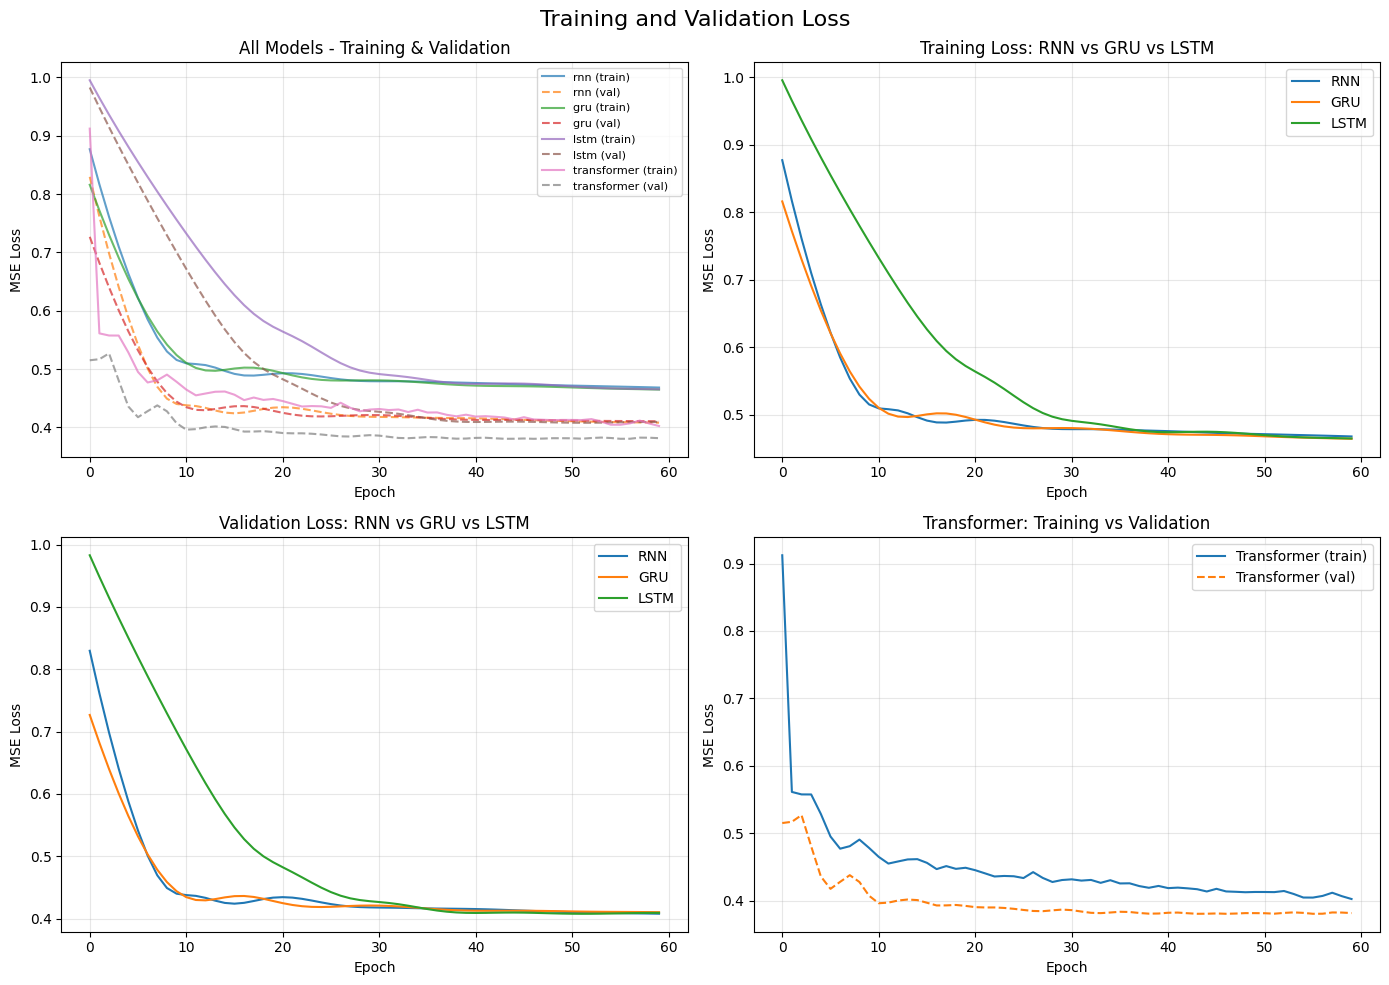

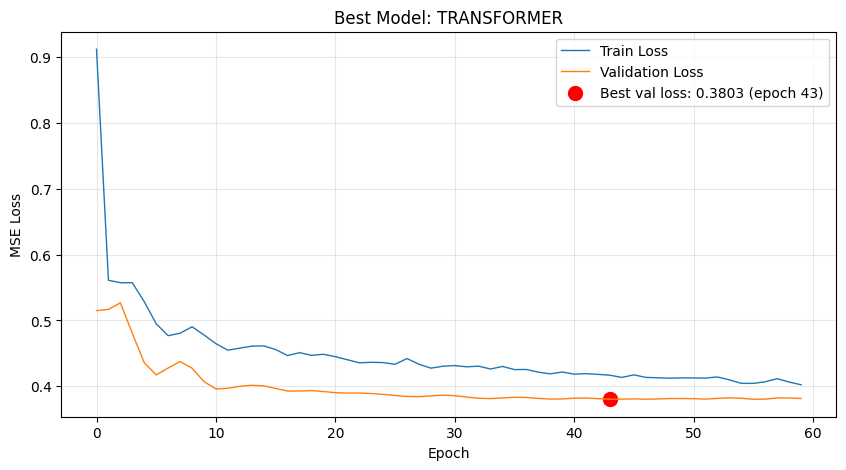

🏆 Лучшая модель: TRANSFORMER
   Лучшая val loss: 0.380301 на эпохе 43


In [46]:
import matplotlib.pyplot as plt

# ========== ПОСТРОЕНИЕ ГРАФИКОВ ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training and Validation Loss', fontsize=16)

# 1. Все модели вместе
ax = axes[0, 0]
for name in history.keys():
    ax.plot(history[name]['train'], label=f'{name} (train)', alpha=0.7)
    ax.plot(history[name]['val'], label=f'{name} (val)', linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('All Models - Training & Validation')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# 2. RNN, GRU, LSTM (train)
ax = axes[0, 1]
for name in ['rnn', 'gru', 'lstm']:
    if name in history:
        ax.plot(history[name]['train'], label=f'{name.upper()}', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss: RNN vs GRU vs LSTM')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. RNN, GRU, LSTM (val)
ax = axes[1, 0]
for name in ['rnn', 'gru', 'lstm']:
    if name in history:
        ax.plot(history[name]['val'], label=f'{name.upper()}', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Validation Loss: RNN vs GRU vs LSTM')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Transformer отдельно (если есть)
ax = axes[1, 1]
if 'transformer' in history:
    ax.plot(history['transformer']['train'], label='Transformer (train)', linewidth=1.5)
    ax.plot(history['transformer']['val'], label='Transformer (val)', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Transformer: Training vs Validation')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No Transformer data', ha='center', va='center')
    ax.set_title('Transformer')

plt.tight_layout()
plt.show()

# ========== ОТДЕЛЬНЫЙ ГРАФИК С ЛУЧШЕЙ МОДЕЛЬЮ ==========
# Находим модель с наименьшим val loss
best_model = min(history.keys(), key=lambda x: min(history[x]['val']))
best_val_loss = min(history[best_model]['val'])
best_epoch = history[best_model]['val'].index(best_val_loss)

plt.figure(figsize=(10, 5))
plt.plot(history[best_model]['train'], label='Train Loss', linewidth=1)
plt.plot(history[best_model]['val'], label='Validation Loss', linewidth=1)
plt.scatter(best_epoch, best_val_loss, color='red', s=100, 
            label=f'Best val loss: {best_val_loss:.4f} (epoch {best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Best Model: {best_model.upper()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"🏆 Лучшая модель: {best_model.upper()}")
print(f"   Лучшая val loss: {best_val_loss:.6f} на эпохе {best_epoch}")

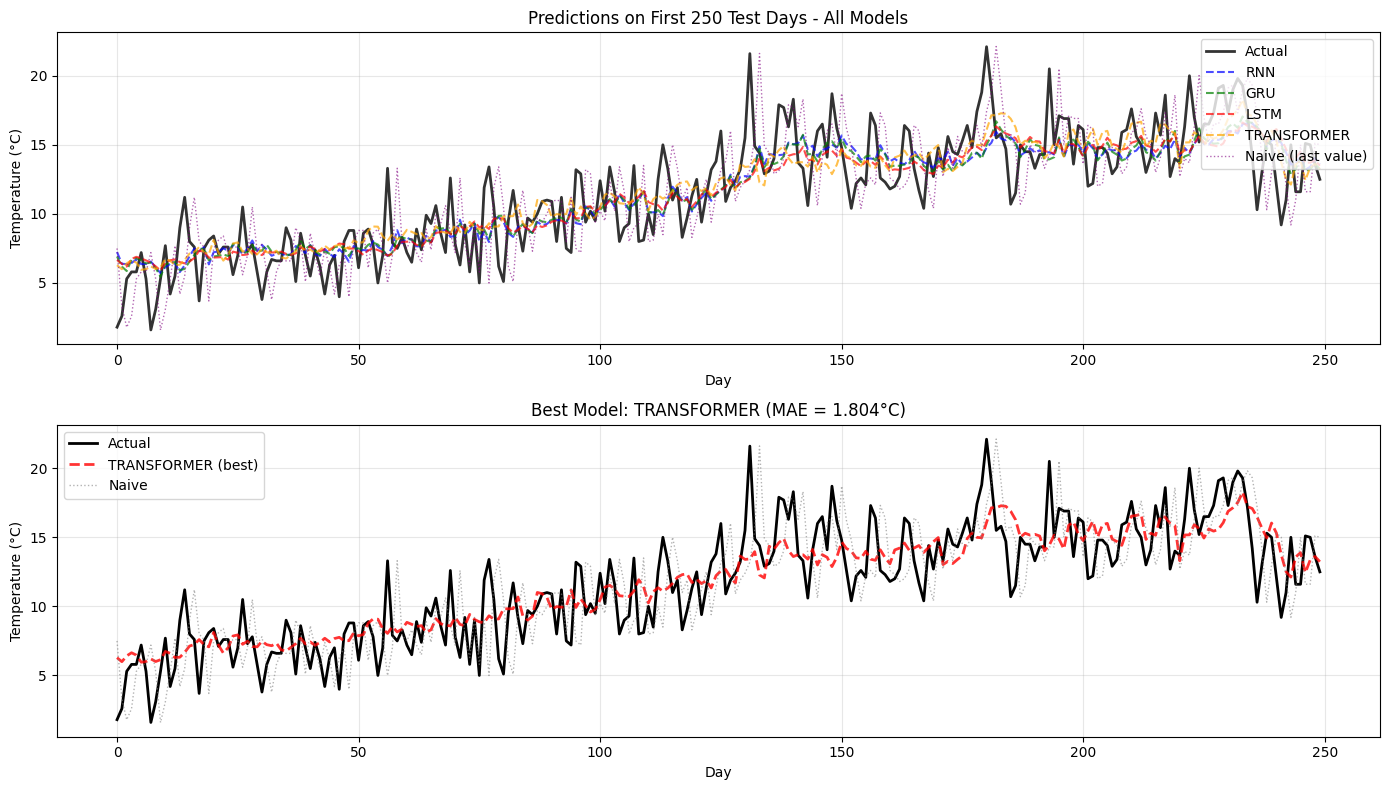

РЕЗУЛЬТАТЫ НА ПЕРВЫХ 250 ДНЯХ ТЕСТА

Model        MAE (°C)     RMSE (°C)    Better than naive 
------------------------------------------------------
RNN          1.885        2.401        ✅ Yes             
GRU          1.887        2.392        ✅ Yes             
LSTM         1.860        2.370        ✅ Yes             
TRANSFORMER  1.804        2.297        ✅ Yes             
Naive        2.483        3.111        -                 


In [47]:
# ========== ПРЕДСКАЗАНИЯ НА ПЕРВЫЕ 250 ДНЕЙ ==========

# Берем первые 250 примеров из тестовой выборки
n_days = 250
X_test_250 = X_te[:n_days]  # (250, seq_len, features)
y_test_250 = y_te[:n_days]  # (250, 1)

# Делаем предсказания всеми моделями
predictions_250 = {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        pred = model(X_test_250).numpy().squeeze()
        # Обратное масштабирование
        pred_original = pred * y_std + y_mean
        predictions_250[name] = pred_original

# Истинные значения (обратное масштабирование)
true_250 = y_test_250.numpy().squeeze() * y_std + y_mean

# Naive baseline для первых 250 дней
naive_250 = X_test_250[:, -1, 0].numpy() * y_std + y_mean

# ========== ВИЗУАЛИЗАЦИЯ ==========
plt.figure(figsize=(14, 8))

# График 1: Все модели
plt.subplot(2, 1, 1)
plt.plot(true_250, label='Actual', color='black', linewidth=2, alpha=0.8)

colors = {'rnn': 'blue', 'gru': 'green', 'lstm': 'red', 'transformer': 'orange'}
for name, pred in predictions_250.items():
    plt.plot(pred, label=f'{name.upper()}', color=colors.get(name, 'gray'), 
             linewidth=1.5, alpha=0.7, linestyle='--')

plt.plot(naive_250, label='Naive (last value)', color='purple', linewidth=1, alpha=0.6, linestyle=':')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title(f'Predictions on First {n_days} Test Days - All Models')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# График 2: Только лучшая модель
plt.subplot(2, 1, 2)

# Находим лучшую модель по MAE на первых 250 днях
best_name = None
best_mae = float('inf')
for name, pred in predictions_250.items():
    mae = np.mean(np.abs(pred - true_250))
    if mae < best_mae:
        best_mae = mae
        best_name = name

plt.plot(true_250, label='Actual', color='black', linewidth=2)
plt.plot(predictions_250[best_name], label=f'{best_name.upper()} (best)', 
         color='red', linewidth=2, alpha=0.8, linestyle='--')
plt.plot(naive_250, label='Naive', color='gray', linewidth=1, alpha=0.6, linestyle=':')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title(f'Best Model: {best_name.upper()} (MAE = {best_mae:.3f}°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== СТАТИСТИКА ==========
print("=" * 60)
print(f"РЕЗУЛЬТАТЫ НА ПЕРВЫХ {n_days} ДНЯХ ТЕСТА")
print("=" * 60)
print(f"\n{'Model':<12} {'MAE (°C)':<12} {'RMSE (°C)':<12} {'Better than naive':<18}")
print("-" * 54)

naive_mae_250 = np.mean(np.abs(naive_250 - true_250))

for name, pred in predictions_250.items():
    mae = np.mean(np.abs(pred - true_250))
    rmse = np.sqrt(np.mean((pred - true_250)**2))
    better = "✅ Yes" if mae < naive_mae_250 else "❌ No"
    print(f"{name.upper():<12} {mae:<12.3f} {rmse:<12.3f} {better:<18}")

print(f"{'Naive':<12} {naive_mae_250:<12.3f} {np.sqrt(np.mean((naive_250 - true_250)**2)):<12.3f} {'-':<18}")